# Rung 3 — Walter remembers (an MLP)

**The question this notebook answers:** how can a model use *more* context without the count table exploding?

Walter has only ever seen one letter back. After `.` he can't tell whether he's at the start of `emma` or the start of `zzyzx`, and after `a` he has no idea whether he's three letters into a name or twelve. To do better he needs to remember more.

The obvious fix, counting triples or quadruples, breaks down almost at once. This notebook shows why, and builds the fix from Bengio et al., *A Neural Probabilistic Language Model* (2003): give every letter a learned **embedding**, then feed a few of them into a small neural network, a **multi-layer perceptron (MLP)**.

From here on PyTorch computes the gradients. Rung 2 showed it gets exactly the same answer as doing it by hand.

In [1]:
import random
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

words = open('../data/names.txt').read().splitlines()
chars = sorted(set(''.join(words)))
stoi = {ch: i + 1 for i, ch in enumerate(chars)}
stoi['.'] = 0
itos = {i: ch for ch, i in stoi.items()}
V = len(stoi)
print(len(words), 'names, vocabulary of', V)

32033 names, vocabulary of 27


## Step 1 — Why counting runs out of road

A model that looks 3 letters back needs a row for every possible 3-letter context: 27³ = **19,683** rows, each with 27 columns. Let's count how many of those contexts the names actually contain, and how often.

In [2]:
from collections import Counter

block_size = 3  # how many letters Walter looks back

ctx_counts = Counter()
for w in words:
    context = [0] * block_size
    for ch in w + '.':
        ctx_counts[tuple(context)] += 1
        context = context[1:] + [stoi[ch]]

print('possible contexts      :', V ** block_size)
print('contexts ever seen     :', len(ctx_counts))
print('seen fewer than 5 times:', sum(c < 5 for c in ctx_counts.values()))
for k in [4, 5, 6]:
    print(f'with {k} letters back, possible contexts = {V ** k:,}')

possible contexts      : 19683
contexts ever seen     : 5686
seen fewer than 5 times: 2495
with 4 letters back, possible contexts = 531,441
with 5 letters back, possible contexts = 14,348,907
with 6 letters back, possible contexts = 387,420,489


Two-thirds of all contexts never appear, and many of the rest appear only a handful of times. For those rows Walter has almost nothing to go on. Every letter of extra memory multiplies the table by 27.

The deeper problem: a count table treats every context as completely separate. Seeing `ana` a thousand times tells it **nothing** about `ena`, even though they behave almost the same. People generalise from similar cases, and a table can't.

## Step 2 — Datasets, and a test Walter has never seen

Every position in every name becomes an example: the **previous 3 letters** → the **next letter**. Start-of-name is padded with `.`.

There's a new rule from now on. A model this flexible could simply *memorise* its training names. To catch that, we split the names three ways and keep that split for the rest of the climb:

- **train** (80%): Walter learns from these
- **dev** (10%): we check our choices (model size, learning rate) against these
- **test** (10%): touched once, at the very end

The number we care about is the **dev loss**: how surprised Walter is by names he has *never seen*.

In [3]:
def build_dataset(words):
    X, Y = [], []
    for w in words:
        context = [0] * block_size
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix]
    return torch.tensor(X), torch.tensor(Y)

random.seed(42)
shuffled = words[:]
random.shuffle(shuffled)
n1, n2 = int(0.8 * len(shuffled)), int(0.9 * len(shuffled))
Xtr, Ytr = build_dataset(shuffled[:n1])
Xdev, Ydev = build_dataset(shuffled[n1:n2])
Xte, Yte = build_dataset(shuffled[n2:])
print('train', tuple(Xtr.shape), ' dev', tuple(Xdev.shape), ' test', tuple(Xte.shape))
for x, y in zip(Xtr[:6], Ytr[:6]):
    print(''.join(itos[i.item()] for i in x), '-->', itos[y.item()])

train (182625, 3)  dev (22655, 3)  test (22866, 3)
... --> y
..y --> u
.yu --> h
yuh --> e
uhe --> n
hen --> g


For a fair comparison, here is the Rung 1 bigram table rebuilt from the **training** names only and scored on the **dev** names. This is the number to beat.

In [4]:
N = torch.zeros((V, V))
for x, y in zip(Xtr[:, -1], Ytr):
    N[x, y] += 1
P = (N + 1) / (N + 1).sum(1, keepdim=True)
bigram_dev = -P[Xdev[:, -1], Ydev].log().mean().item()
print(f'bigram (Rung 1) dev loss: {bigram_dev:.4f}')

bigram (Rung 1) dev loss: 2.4533


## Step 3 — Embeddings: every letter becomes a point in space

This is the key idea of the whole rung. Instead of a one-hot vector, every letter gets a short list of numbers, here 10 of them, called its **embedding**. All 27 embeddings live in one learnable table `C` of shape 27 × 10.

At the start these numbers are random. During training, letters that behave alike get pushed towards similar embeddings, because that lets the rest of the network treat them alike. That's how seeing `ana` can help with `ena`.

Looking up an embedding is just `C[ix]`. Recall from Rung 2 that one-hot × matrix **is** a row lookup, so an embedding table is exactly Rung 2's first layer with a narrower output.

In [5]:
g = torch.Generator().manual_seed(2026)
C_demo = torch.randn((V, 10), generator=g)
ix = torch.tensor([stoi['e']])
print('C[e]            :', C_demo[ix].squeeze().numpy().round(2))
print('one_hot(e) @ C  :', (F.one_hot(ix, V).float() @ C_demo).squeeze().numpy().round(2))

C[e]            : [-0.08 -0.41  0.46  1.13  0.05 -0.89  0.4  -0.47 -1.21 -1.57]
one_hot(e) @ C  : [-0.08 -0.41  0.46  1.13  0.05 -0.89  0.4  -0.47 -1.21 -1.57]


## Step 4 — The network

For each example:

1. **Look up** the 3 context letters in `C`, giving 3 × 10 numbers, and lay them side by side as one vector of 30.
2. **Hidden layer**: 200 neurons, each computing a weighted sum of those 30 numbers and squashing it with `tanh`. This is the part that combines the letters, so it can notice things like "a vowel, then `n`, then `n`".
3. **Output layer**: 27 logits, then the same softmax and loss as Rung 2.

```
 3 letters → C → [30] → W1,b1 → tanh → [200] → W2,b2 → [27] → softmax
```

**A word on starting values.** If the output layer starts with large random weights, Walter starts out confidently wrong (Rung 2's random Walter scored 3.78, worse than guessing). We start him *humble* instead: the output weights are scaled down so his first guesses are close to uniform, a loss of ≈ 3.30. The hidden-layer weights are scaled by `(5/3)/√30` so the `tanh` neurons start in their responsive range rather than stuck at ±1. Both tricks just save training time that would otherwise go to undoing a bad start.

In [6]:
n_embd, n_hidden = 10, 200

g = torch.Generator().manual_seed(2026)
C  = torch.randn((V, n_embd), generator=g)
W1 = torch.randn((block_size * n_embd, n_hidden), generator=g) * (5 / 3) / (block_size * n_embd) ** 0.5
b1 = torch.randn(n_hidden, generator=g) * 0.01
W2 = torch.randn((n_hidden, V), generator=g) * 0.01
b2 = torch.zeros(V)
parameters = [C, W1, b1, W2, b2]
for p in parameters:
    p.requires_grad = True

def forward(X):
    emb = C[X]                                   # (batch, 3, 10)
    h = torch.tanh(emb.view(len(X), -1) @ W1 + b1)   # (batch, 200)
    return h @ W2 + b2                           # (batch, 27) logits

print('parameters:', sum(p.nelement() for p in parameters))
with torch.no_grad():
    print('loss before any training:', round(F.cross_entropy(forward(Xtr), Ytr).item(), 4), '(uniform is 3.2958)')

parameters: 11897
loss before any training: 3.3047 (uniform is 3.2958)


Walter now has about 11,900 numbers to tune, against 729 in Rungs 1 and 2. Even so that's tiny next to the 19,683 × 27 ≈ **531,000** entries a 3-letter count table would need, and he will generalise where the table can't.

## Step 5 — Training on mini-batches

Rung 2 computed the gradient over *all* 228,000 examples before every step. That's exact, but slow. Here, each step looks at a random **mini-batch** of just 32 examples. The gradient is noisier, but it's thousands of times cheaper, and noisy steps in roughly the right direction beat perfect steps taken rarely. This is **stochastic gradient descent**.

We also lower the learning rate after half of training. Big steps get Walter into the right valley, and small steps let him settle at the bottom.

In [7]:
max_steps, batch_size = 200_000, 32
lossi = []
for step in range(max_steps):
    ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
    loss = F.cross_entropy(forward(Xtr[ix]), Ytr[ix])

    for p in parameters:
        p.grad = None
    loss.backward()

    lr = 0.1 if step < 100_000 else 0.01
    for p in parameters:
        p.data += -lr * p.grad

    lossi.append(loss.log10().item())
    if step % 20_000 == 0:
        print(f'step {step:7d}/{max_steps}  minibatch loss {loss.item():.4f}')

step       0/200000  minibatch loss 3.3117


step   20000/200000  minibatch loss 1.8431


step   40000/200000  minibatch loss 2.4637


step   60000/200000  minibatch loss 2.7577


step   80000/200000  minibatch loss 2.1952


step  100000/200000  minibatch loss 2.1848


step  120000/200000  minibatch loss 1.9915


step  140000/200000  minibatch loss 2.2339


step  160000/200000  minibatch loss 2.4192


step  180000/200000  minibatch loss 2.2716


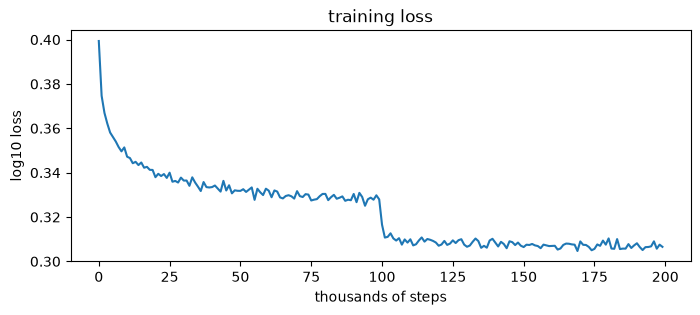

In [8]:
plt.figure(figsize=(8, 3))
plt.plot(torch.tensor(lossi).view(-1, 1000).mean(1))   # average every 1000 steps to see the trend
plt.xlabel('thousands of steps'); plt.ylabel('log10 loss'); plt.title('training loss')
plt.show()

The drop in the middle is where the learning rate falls from 0.1 to 0.01.

## Step 6 — The verdict: dev loss

In [9]:
@torch.no_grad()
def split_loss(X, Y):
    return F.cross_entropy(forward(X), Y).item()

train_loss, dev_loss = split_loss(Xtr, Ytr), split_loss(Xdev, Ydev)
print(f'uniform guessing : {torch.log(torch.tensor(27.)).item():.4f}')
print(f'bigram (Rung 1)  : {bigram_dev:.4f}  (dev)')
print(f'MLP    (Rung 3)  : {dev_loss:.4f}  (dev)    train {train_loss:.4f}')

uniform guessing : 3.2958
bigram (Rung 1)  : 2.4533  (dev)
MLP    (Rung 3)  : 2.1136  (dev)    train 2.0405


Walter is clearly better than the bigram table, and on names he has **never seen**. Train and dev loss are close together, which means he learned patterns rather than memorising the training names. A big gap, with train much lower than dev, would be the sign of memorising (**overfitting**).

## Step 7 — Look inside: what did the embeddings learn?

Each letter is now a point in 10 dimensions. We can't see 10-D, so we flatten it to the 2 directions where the points are most spread out (**PCA**) and plot it. Nobody told Walter what a vowel is.

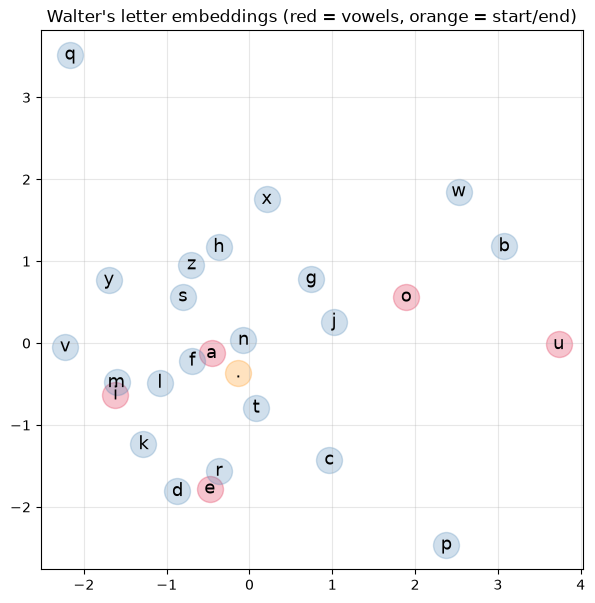

In [10]:
with torch.no_grad():
    E = C - C.mean(0)
    U, S, Vh = torch.linalg.svd(E, full_matrices=False)
    xy = (E @ Vh[:2].T).numpy()

vowels = set('aeiou')
plt.figure(figsize=(7, 7))
for i in range(V):
    ch = itos[i]
    color = 'crimson' if ch in vowels else ('darkorange' if ch == '.' else 'steelblue')
    plt.scatter(xy[i, 0], xy[i, 1], s=350, color=color, alpha=0.25)
    plt.text(xy[i, 0], xy[i, 1], ch, ha='center', va='center', fontsize=13)
plt.title("Walter's letter embeddings (red = vowels, orange = start/end)")
plt.grid(alpha=0.3)
plt.show()

The vowels clump together, apart from the consonants, and `.` (start/end) sits off on its own. Walter invented the idea of a vowel because it helped him predict, and an embedding is what an invented idea looks like as numbers. This is our first small piece of *interpretability*: reading a concept straight out of the weights. Rung 6 does this properly.

## Step 8 — Walter speaks

In [11]:
g_sample = torch.Generator().manual_seed(2026)
train_set = set(shuffled[:n1])
samples = []
for _ in range(20):
    out, context = [], [0] * block_size
    while True:
        with torch.no_grad():
            probs = F.softmax(forward(torch.tensor([context])), dim=1)
        ix = torch.multinomial(probs, 1, generator=g_sample).item()
        if ix == 0:
            break
        out.append(itos[ix])
        context = context[1:] + [ix]
    samples.append(''.join(out))
print('\n'.join(f'{s:15s}' + ('' if s in train_set else '  (new)') for s in samples))

sory             (new)
dorhan           (new)
brennon        
naye             (new)
mariona        
son            
ailee          
nazaleanavionni  (new)
bayah            (new)
mar            
ramelli          (new)
daleximoni       (new)
hayna            (new)
abi              (new)
tate           
solan          
zah              (new)
sevan          
kandrux          (new)
daisa            (new)


Much more name-like than Rung 1. Lengths are sensible and the letter clusters look real. Many of these names don't exist in the training set: Walter is **inventing** names, not reciting them.

## Step 9 — The test set, touched once

We tuned nothing on the test names, so this is an honest estimate of how Walter does on new names.

In [12]:
print(f'MLP test loss: {split_loss(Xte, Yte):.4f}')

MLP test loss: 2.1104


## What just happened

1. **Counting doesn't scale**: more context makes tables exponentially huge and mostly empty.
2. **Embeddings**: each letter became a learned point in space, so similar letters can share what they learn.
3. **An MLP** combined the 3 context embeddings through a hidden layer of `tanh` neurons.
4. **Train / dev / test** let us measure what really matters: performance on names Walter has never seen.
5. **Mini-batch SGD** made training cheap enough to run 200,000 steps.
6. Walter **invented the vowel**, visible right in his embeddings.

## Your turn (do these before Rung 4)
- Set `block_size = 5`. Does dev loss improve? What does it cost in parameters?
- Shrink `n_embd` to 2 and plot the embeddings directly with no PCA. What still clusters?
- Delete the `* 0.01` on `W2`. What's the loss at step 0 now, and does the final dev loss suffer?
- Find the learning rate that's too high: try 1.0. What does the loss curve do?

**Next — Rung 4:** this MLP still has a fixed window. It sees exactly 3 letters, and each slot is wired to its own weights, so "an `a` two letters back" and "an `a` three letters back" are learned separately. **Attention** lets Walter look back over the *whole* name and decide for himself which earlier letters matter.